In [5]:
import pandas as pd

In [6]:
df=pd.read_csv('data\invoice_train.csv')
df_client=pd.read_csv('data\client_train.csv')

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\youss\AppData\Local\Temp\ipykernel_8448\3627842812.py:1: SyntaxWarning: invalid escape sequence '\i'
  df=pd.read_csv('data\invoice_train.csv')
C:\Users\youss\AppData\Local\Temp\ipykernel_8448\3627842812.py:2: SyntaxWarning: invalid escape sequence '\c'
  df_client=pd.read_csv('data\client_train.csv')
C:\Users\youss\AppData\Local\Temp\ipykernel_8448\3627842812.py:1: DtypeWarning: Columns (0: counter_statue) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('data\invoice_train.csv')


In [7]:
df.shape

(4476749, 16)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             str   
 1   invoice_date          str   
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          str   
dtypes: int64(12), object(1), str(3)
memory usage: 546.5+ MB


In [9]:
df_client.shape

(135493, 6)

In [10]:
#we start by cleaning the data

In [11]:
mis = df.isnull().sum()
mis = mis[mis > 0]
print(mis)
#there is no missing value in the columns

Series([], dtype: int64)


In [12]:
#lets verifie ....
df.tarif_type.unique()

array([11, 40, 15, 10, 12, 14, 13, 45, 29,  9, 30,  8, 21, 42, 27, 18, 24])

In [13]:
df['tarif_type'].value_counts()
#done

tarif_type
11    2679872
40    1379755
10     276210
15      72422
45      17552
13      11656
14      11611
12      11345
29      10090
9        6039
21        104
8          43
30         35
24          9
18          4
42          1
27          1
Name: count, dtype: int64

In [14]:
df.counter_number.unique()

array([1335667,  678902,  572765, ..., 4811719,  262195,  560948],
      shape=(201893,))

In [15]:
df.counter_number.value_counts()
#this column can't be considered an Id so we delete this column

counter_number
0                 43161
2786                251
630317              230
162709              226
963                 220
                  ...  
2185800008930         1
27181146875900        1
3122275               1
4173829               1
2426                  1
Name: count, Length: 201893, dtype: int64

In [16]:
df=df.drop(columns=['counter_number'])

In [17]:
df.counter_statue.unique()


array([0, 1, 5, 4, 3, 2, 769, '0', '5', '1', '4', 'A', 618, 269375, 46,
       420], dtype=object)

In [18]:
df.counter_statue.value_counts()

counter_statue
0         4346960
1           73496
0           32048
5           20495
4            2706
1             540
3             258
5             144
2              32
4              23
46             14
A              13
618            12
769             6
269375          1
420             1
Name: count, dtype: int64

In [19]:
#we need to handle str 0,1,4,5 in str form
#A is usuely considered good so will fill it with 5
#for the rest we will fill it with most frequente value

In [20]:
df["counter_statue"]=df["counter_statue"].apply(
    lambda x : int(x) if str(x).isdigit() else x
)

counter_statue
5         0.104608
4         0.086112
0         0.078852
3         0.073643
1         0.072965
2         0.062500
269375    0.000000
420       0.000000
46        0.000000
618       0.000000
769       0.000000
A         0.000000
Name: target, dtype: float64


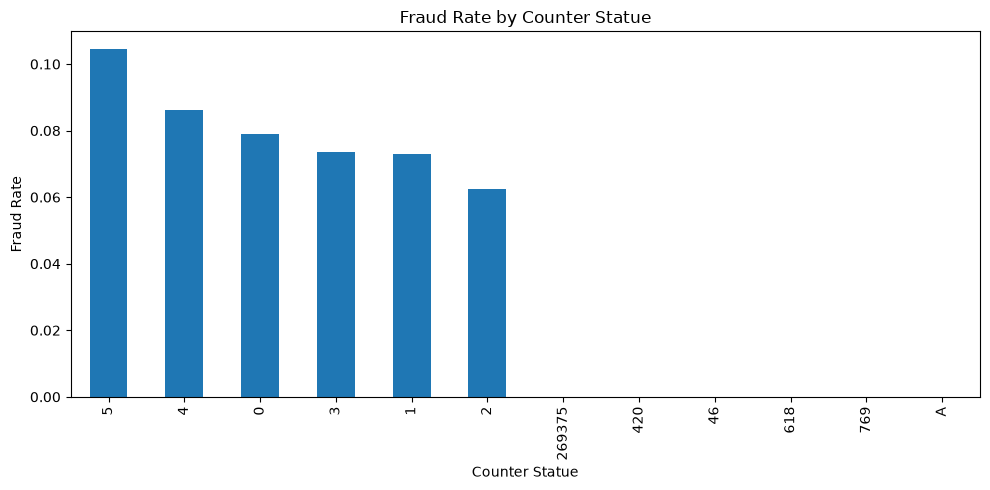

In [21]:
import matplotlib.pyplot as plt


df['counter_statue'] = df['counter_statue'].astype(str)


df_merged = df.merge(df_client[['client_id', 'target']], on='client_id', how='left')


fraud_by_status = df_merged.groupby('counter_statue')['target'].mean().sort_values(ascending=False)
print(fraud_by_status)


fraud_by_status.plot(kind='bar', figsize=(10,5))
plt.title('Fraud Rate by Counter Statue')
plt.xlabel('Counter Statue')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [22]:
#we gonna fill the weird values with mode
mode=df['counter_statue'].mode()[0]
weird_values=['269375', '420', '46', '618', '769', 'A']
df['counter_statue']=df['counter_statue'].replace(weird_values,mode)

In [23]:
df.counter_statue.unique()

<StringArray>
['0', '1', '5', '4', '3', '2']
Length: 6, dtype: str

In [24]:
df.counter_code.unique()

array([203, 207, 413,   5, 467, 202, 420, 410,  10, 483,  25, 433, 407,
       204, 214, 442, 453, 506, 450, 403, 333, 201, 102, 305, 210, 101,
       532,  40, 310, 565, 600, 307, 303, 222,  65,   0, 227, 325,  16,
       317, 367,   1])

In [25]:
df.counter_code.value_counts()
#no idea

counter_code
203    1516836
5      1352035
207     555628
413     378917
202     343251
420      98273
410      69080
433      34447
10       27744
442      17050
25       14934
407      13768
204      12427
453       8290
201       7672
467       7302
506       3389
483       2830
214       2643
40        2482
532       1982
565       1082
403       1070
450       1059
600        807
210        789
102        313
227        178
101         74
65          74
16          73
310         51
307         50
305         44
222         42
0           33
317         16
303          5
333          4
367          3
325          1
1            1
Name: count, dtype: int64

              fraud_rate    count
counter_code                     
40              0.278405     2482
600             0.236679      807
407             0.180709    13768
25              0.177380    14934
10              0.129578    27744
214             0.127507     2643
204             0.122556    12427
210             0.115336      789
433             0.114495    34447
453             0.111460     8290
403             0.107477     1070
202             0.096515   343251
506             0.094423     3389
420             0.087481    98273
413             0.082881   378917
5               0.081231  1352035
442             0.079824    17050
203             0.074940  1516836
201             0.072341     7672
410             0.071699    69080
450             0.063267     1059
207             0.057848   555628
467             0.056834     7302
227             0.056180      178
483             0.037809     2830
16              0.027397       73
565             0.001848     1082
102           

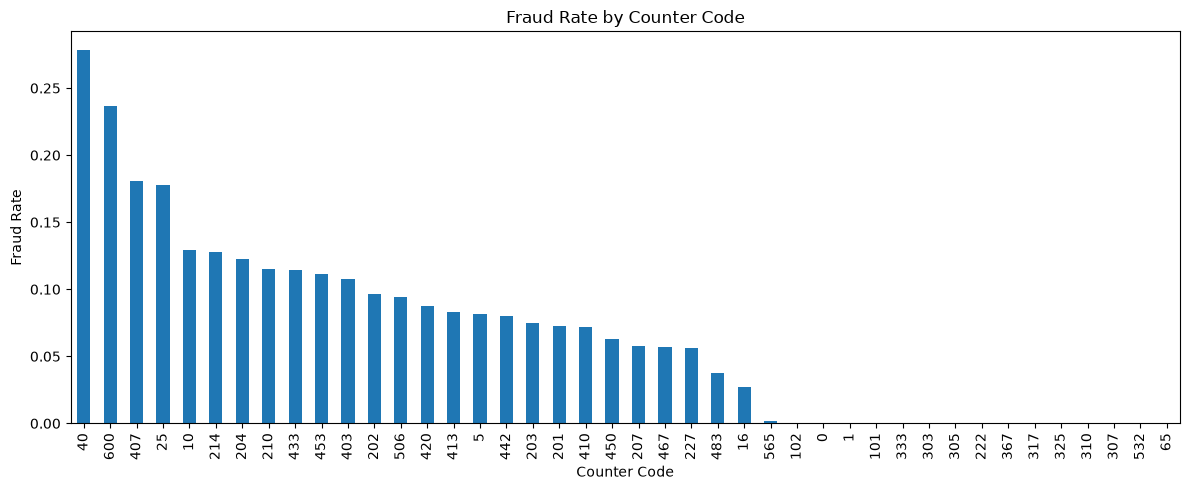

In [26]:
import matplotlib.pyplot as plt

df['counter_code'] = df['counter_code'].astype(str)

df_merged = df.merge(df_client[['client_id', 'target']], on='client_id', how='left')

fraud_by_code = df_merged.groupby('counter_code')['target'].mean().sort_values(ascending=False)

count_by_code = df['counter_code'].value_counts()

summary = pd.DataFrame({
    'fraud_rate': fraud_by_code,
    'count': count_by_code
}).sort_values('fraud_rate', ascending=False)

print(summary)


fraud_by_code.plot(kind='bar', figsize=(12,5))
plt.title('Fraud Rate by Counter Code')
plt.xlabel('Counter Code')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [27]:
rare_values=['101', '65', '16', '310', '307', '305', '222', '0', '317', '303', '333', '367', '325', '1']
df['counter_code'] =df['counter_code'].replace(rare_values,5009)

In [28]:
df.counter_code.value_counts()

counter_code
203     1516836
5       1352035
207      555628
413      378917
202      343251
420       98273
410       69080
433       34447
10        27744
442       17050
25        14934
407       13768
204       12427
453        8290
201        7672
467        7302
506        3389
483        2830
214        2643
40         2482
532        1982
565        1082
403        1070
450        1059
600         807
210         789
5009        471
102         313
227         178
Name: count, dtype: int64

In [29]:
df.counter_code.unique()

array(['203', '207', '413', '5', '467', '202', '420', '410', '10', '483',
       '25', '433', '407', '204', '214', '442', '453', '506', '450',
       '403', 5009, '201', '102', '210', '532', '40', '565', '600', '227'],
      dtype=object)

In [30]:
df.reading_remarque.unique()

array([  8,   6,   9,   7, 207, 413, 203,   5])

In [31]:
df.reading_remarque.value_counts()

reading_remarque
6      2230939
9      1416992
8       828123
7          661
203         15
413         12
207          6
5            1
Name: count, dtype: int64

In [32]:
df_merged = df.merge(df_client[['client_id', 'target']], on='client_id', how='left')
df_merged.groupby('reading_remarque')['target'].mean().sort_values(ascending=False)

reading_remarque
8      0.081834
9      0.080032
6      0.077070
7      0.001513
5      0.000000
203    0.000000
207    0.000000
413    0.000000
Name: target, dtype: float64

In [33]:
#group weird values in one categorie usining a random number
values = [5,203,207,7,413]
df['reading_remarque']=df['reading_remarque'].replace(values,101)

In [34]:
df.reading_remarque.value_counts()

reading_remarque
6      2230939
9      1416992
8       828123
101        695
Name: count, dtype: int64

In [35]:
df.counter_coefficient.unique()

array([ 1,  3,  0, 10,  4, 33, 50, 20,  2,  6, 40,  9, 30,  5, 11,  8])

In [36]:
df.counter_coefficient.value_counts()

counter_coefficient
1     4475102
2         886
3         321
40        197
30        137
0          46
6          30
4          12
10          6
20          3
9           3
50          2
33          1
5           1
11          1
8           1
Name: count, dtype: int64

In [37]:

df['counter_coefficient']=df['counter_coefficient'].apply(lambda x: 11 if x!=1
else 1)

In [38]:
df.counter_coefficient.value_counts()

counter_coefficient
1     4475102
11       1647
Name: count, dtype: int64

In [39]:
df.months_number.unique()

array([     4,     12,      8, ..., 367445, 459733, 463554], shape=(1370,))

In [40]:
df.months_number.value_counts()

months_number
4         3680478
8          278772
2          270909
1          113266
12          54328
           ...   
461273          1
364360          1
367445          1
459733          1
463554          1
Name: count, Length: 1370, dtype: int64

In [41]:
df['months_number'].apply(lambda x: x if x<=36 else 40)

0           4
1           4
2           4
3           4
4          12
           ..
4476744     8
4476745     4
4476746     4
4476747     4
4476748     4
Name: months_number, Length: 4476749, dtype: int64

In [42]:
df.months_number.value_counts()

months_number
4         3680478
8          278772
2          270909
1          113266
12          54328
           ...   
461273          1
364360          1
367445          1
459733          1
463554          1
Name: count, Length: 1370, dtype: int64

In [43]:
df.head(15)

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
5,train_Client_0,2017-07-17,11,0,207,9,1,314,0,0,0,15638,15952,8,ELEC
6,train_Client_0,2018-12-07,11,0,207,9,1,541,0,0,0,15952,16493,12,ELEC
7,train_Client_0,2019-03-19,11,0,207,9,1,585,0,0,0,16493,17078,8,ELEC
8,train_Client_0,2011-07-22,11,0,203,9,1,1200,186,0,0,7770,9156,4,ELEC
9,train_Client_0,2011-11-22,11,0,203,6,1,1082,0,0,0,9156,10238,4,ELEC


In [44]:
df.consommation_level_1.value_counts()

consommation_level_1
0        467553
800      247953
200      151245
1200     139628
300       40313
          ...  
17228         1
12887         1
43053         1
4824          1
8314          1
Name: count, Length: 8295, dtype: int64

In [45]:
df.groupby('tarif_type').consommation_level_1.max()

tarif_type
8        478
9      35070
10      8000
11     99920
12     93385
13     85366
14     74971
15     23178
18       391
21      9340
24         0
27         0
29     98889
30       554
40     57600
42         0
45    999910
Name: consommation_level_1, dtype: int64

In [46]:
df

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,0,202,9,1,400,135,0,0,3197,3732,8,ELEC
4476745,train_Client_99998,2005-12-19,10,0,202,6,1,200,6,0,0,3732,3938,4,ELEC
4476746,train_Client_99999,1996-09-25,11,0,203,6,1,259,0,0,0,13884,14143,4,ELEC
4476747,train_Client_99999,1996-05-28,11,0,203,6,1,603,0,0,0,13281,13884,4,ELEC


In [47]:
#for consumtion level 1 my idea is to add anew column (did client depased the max y/n)

In [48]:
thresholds_all = df.groupby('tarif_type')['consommation_level_1'].agg(lambda x: x.value_counts().idxmax())
thresholds_all

tarif_type
8       0
9       0
10    200
11    800
12      0
13      0
14      0
15      0
18    391
21      0
24      0
27      0
29      0
30      0
40      0
42      0
45      0
Name: consommation_level_1, dtype: int64

In [49]:
#a lot of client have no consomtion so we will procced manully

In [50]:
df[df['tarif_type']==8].consommation_level_1.value_counts()

consommation_level_1
0      42
478     1
Name: count, dtype: int64

In [51]:
df.query('tarif_type==8 & consommation_level_1==478')
#verifing consomation level 2

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
1943144,train_Client_31037,2012-02-20,8,0,202,6,11,478,0,0,0,0,478,4,ELEC


In [52]:
#tarif->478

In [53]:
df[df['tarif_type']==9].consommation_level_1.value_counts()

consommation_level_1
0       428
211      12
556      12
618      12
405      11
       ... 
4920      1
1326      1
3026      1
1114      1
90        1
Name: count, Length: 2161, dtype: int64

In [54]:
df.query('tarif_type==9 &  consommation_level_2>0')
#this tells that 211 is not the thread

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type


In [55]:
df.query('tarif_type==9 & consommation_level_1==618 & consommation_level_2>0')
#fill with 2 meaninfg we were anable to determine the thread

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type


In [56]:
df[df['tarif_type']==10].consommation_level_1.value_counts()

consommation_level_1
200     112477
0        13580
800      12166
400       8906
100       4088
         ...  
2544         1
6224         1
2370         1
4672         1
3491         1
Name: count, Length: 2224, dtype: int64

In [57]:
df.query('tarif_type==10 &consommation_level_1==200 & consommation_level_2>0 ')

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
1613,train_Client_100044,2012-06-04,10,0,202,6,1,200,54,0,0,9723,9977,4,ELEC
1614,train_Client_100044,2011-08-12,10,0,202,6,1,200,63,0,0,9460,9723,4,ELEC
1615,train_Client_100044,2011-04-13,10,0,202,6,1,200,60,0,0,9040,9300,4,ELEC
1616,train_Client_100044,2010-09-12,10,0,202,6,1,200,118,0,0,8722,9040,4,ELEC
1617,train_Client_100044,2010-03-08,10,0,202,6,1,200,11,0,0,8511,8722,4,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476584,train_Client_99993,2007-08-21,10,0,202,6,1,200,15,0,0,1515,1730,4,ELEC
4476585,train_Client_99993,2007-12-18,10,0,202,6,1,200,60,0,0,1730,1990,4,ELEC
4476586,train_Client_99993,2013-01-08,10,0,202,8,1,200,228,0,0,12938,13366,4,ELEC
4476587,train_Client_99993,2007-04-24,10,0,202,6,1,200,879,0,0,436,1515,4,ELEC


In [58]:
#tarif 10->200

In [59]:
df[df['tarif_type']==11].consommation_level_1.value_counts()

consommation_level_1
800     235653
0       145763
1200    139443
300      38611
200      36872
         ...  
4962         1
8041         1
6791         1
3311         1
4128         1
Name: count, Length: 4476, dtype: int64

In [60]:
df.query('tarif_type==11 &consommation_level_1==800 & consommation_level_2>0 ')

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
110,train_Client_1000,2015-02-13,11,0,207,9,1,800,159,0,0,0,959,4,ELEC
111,train_Client_1000,2017-09-02,11,0,207,9,1,800,109,0,0,6535,7444,4,ELEC
113,train_Client_1000,2017-11-10,11,0,207,9,1,800,400,800,382,8215,10597,4,ELEC
120,train_Client_1000,2016-12-10,11,0,207,9,1,800,400,800,132,4403,6535,4,ELEC
123,train_Client_1000,2015-08-10,11,0,207,9,1,800,400,43,0,1624,2867,4,ELEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476518,train_Client_99991,2016-12-02,11,0,207,9,1,800,122,0,0,2579,3501,4,ELEC
4476533,train_Client_99991,2017-08-02,11,0,207,9,1,800,219,0,0,5251,6270,4,ELEC
4476535,train_Client_99991,2016-12-10,11,0,207,9,1,800,251,0,0,4200,5251,4,ELEC
4476548,train_Client_99992,2017-02-17,11,0,207,9,1,800,400,12,0,19308,20520,4,ELEC


In [61]:
#tarif type 11 ->800

In [62]:
df[df['tarif_type']==12].consommation_level_1.value_counts()

consommation_level_1
0       7948
1         62
2         47
5         38
6         37
        ... 
707        1
1319       1
2577       1
1371       1
3661       1
Name: count, Length: 1401, dtype: int64

In [63]:
#fill with 2 

In [64]:
df[df['tarif_type']==13].consommation_level_1.value_counts()

consommation_level_1
0       3791
1         89
3         46
2         45
4         36
        ... 
2264       1
1972       1
8314       1
3385       1
3780       1
Name: count, Length: 3511, dtype: int64

In [65]:
#fill with  2 

In [66]:
df[df['tarif_type']==14].consommation_level_1.value_counts()

consommation_level_1
0       5219
1         76
2         55
3         43
4         39
        ... 
2206       1
2753       1
6245       1
1877       1
1991       1
Name: count, Length: 2845, dtype: int64

In [67]:
##fill with  2 

In [68]:
df[df['tarif_type']==15].consommation_level_1.value_counts()

consommation_level_1
0       48289
1         788
2         408
3         331
4         282
        ...  
1840        1
1554        1
1052        1
2603        1
2536        1
Name: count, Length: 1753, dtype: int64

In [69]:
##fill with  2 

In [70]:
df[df['tarif_type']==18].consommation_level_1.value_counts()

consommation_level_1
391    1
190    1
208    1
0      1
Name: count, dtype: int64

In [71]:
df.query('tarif_type==18 & consommation_level_2>0')

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type


In [72]:
#tarif 18 ->391

In [73]:
df[df['tarif_type']==21].consommation_level_1.value_counts()

consommation_level_1
0       17
12       2
22       2
637      1
260      1
        ..
733      1
2369     1
106      1
408      1
1772     1
Name: count, Length: 86, dtype: int64

In [74]:
df.query('tarif_type==21 & consommation_level_2>0')

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type


In [75]:
#fill with  2 

In [76]:
df[df['tarif_type']==24].consommation_level_1.value_counts()

consommation_level_1
0    9
Name: count, dtype: int64

In [77]:
#tarif 24 ->0

In [78]:
df[df['tarif_type']==27].consommation_level_1.value_counts()

consommation_level_1
0    1
Name: count, dtype: int64

In [79]:
#tarif 27 ->0

In [80]:
df[df['tarif_type']==29].consommation_level_1.value_counts()

consommation_level_1
0       4109
1         90
2         40
3         36
4         28
        ... 
567        1
1639       1
2142       1
2644       1
2292       1
Name: count, Length: 2326, dtype: int64

In [81]:
#fill with  2 

In [82]:
df[df['tarif_type']==30].consommation_level_1.value_counts()

consommation_level_1
0      16
24      2
337     2
114     1
76      1
48      1
554     1
103     1
13      1
34      1
319     1
270     1
536     1
346     1
540     1
9       1
276     1
387     1
Name: count, dtype: int64

In [83]:
df.query('tarif_type==30 & consommation_level_2>0')

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type


In [84]:
#tarif type30 -> 554

In [85]:
df[df['tarif_type']==40].consommation_level_1.value_counts()

consommation_level_1
0       236710
1         9472
2         6697
60        6453
70        6425
         ...  
4489         1
4234         1
3245         1
5390         1
4304         1
Name: count, Length: 5153, dtype: int64

In [86]:
df.query('tarif_type==40 & consommation_level_2>0')

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
658126,train_Client_11774,2011-06-28,40,1,5,9,11,7,202,0,0,0,0,6,GAZ
1390109,train_Client_15805,2009-07-20,40,0,5,8,11,1,4,0,0,0,2,43,GAZ
2226693,train_Client_38765,2007-11-27,40,0,5,6,1,2,225,0,0,0,842,1030,GAZ
2226707,train_Client_38765,2008-04-04,40,0,5,9,1,2,1723,0,0,0,1030,2466,GAZ
2226709,train_Client_38765,2008-01-08,40,0,5,6,1,2,21,0,0,0,2657,2675,GAZ
2226725,train_Client_38765,2007-07-30,40,0,5,6,1,2,133,0,0,0,661,772,GAZ
2226738,train_Client_38765,2008-11-28,40,0,5,6,1,2,174,0,0,0,2740,2885,GAZ
2226742,train_Client_38765,2006-07-28,40,0,5,6,1,2,156,0,0,0,0,130,GAZ
2226744,train_Client_38765,2007-03-04,40,0,5,9,1,2,568,0,0,0,187,661,GAZ
2226755,train_Client_38765,2009-03-08,40,0,5,8,1,2,36,0,0,0,4565,4595,GAZ


In [87]:
#fill with  2 

In [88]:
df[df['tarif_type']==42].consommation_level_1.value_counts()

consommation_level_1
0    1
Name: count, dtype: int64

In [89]:
#tarif 42 ->0

In [90]:
df[df['tarif_type']==45].consommation_level_1.value_counts()

consommation_level_1
0        1629
3         927
2          19
4          18
1          17
         ... 
474         1
17870       1
3555        1
675         1
3850        1
Name: count, Length: 5145, dtype: int64

In [91]:
#fill with  2 

In [92]:
df.tarif_type.unique()

array([11, 40, 15, 10, 12, 14, 13, 45, 29,  9, 30,  8, 21, 42, 27, 18, 24])

In [93]:
fill_with_2=[9,12,13,14,15,21,29,40,45]
tarif_max: dict[int,int]={8:478,10:200,11:800,18:351,24:0,27:0,30:554,42:0}

In [102]:
def exceed(row) :
    tarif=row['tarif_type']
    if tarif in fill_with_2 :
        return 2
    elif tarif in tarif_max and row['consommation_level_1']>tarif_max[tarif] :
        return 1
    else :
        return 0
    

In [100]:
df.columns

Index(['client_id', 'invoice_date', 'tarif_type', 'counter_statue',
       'counter_code', 'reading_remarque', 'counter_coefficient',
       'consommation_level_1', 'consommation_level_2', 'consommation_level_3',
       'consommation_level_4', 'old_index', 'new_index', 'months_number',
       'counter_type', 'exceed_max'],
      dtype='str')

In [104]:
df['exceed_max']=df.apply(exceed,axis=1)

In [105]:
df

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,exceed_max
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,0,14302,14384,4,ELEC,0
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC,1
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,0,14624,14747,4,ELEC,0
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,0,14747,14849,4,ELEC,0
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,0,15066,15638,12,ELEC,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,0,202,9,1,400,135,0,0,3197,3732,8,ELEC,1
4476745,train_Client_99998,2005-12-19,10,0,202,6,1,200,6,0,0,3732,3938,4,ELEC,0
4476746,train_Client_99999,1996-09-25,11,0,203,6,1,259,0,0,0,13884,14143,4,ELEC,0
4476747,train_Client_99999,1996-05-28,11,0,203,6,1,603,0,0,0,13281,13884,4,ELEC,0


In [106]:
df.exceed_max.value_counts()

exceed_max
0    2441277
2    1520574
1     514898
Name: count, dtype: int64

In [107]:
df_client

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0
...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0
135489,63,train_Client_99996,11,311,25/10/2012,0.0
135490,63,train_Client_99997,11,311,22/11/2011,0.0
135491,60,train_Client_99998,11,101,22/12/1993,0.0


In [111]:
df_merged=pd.merge(df,df_client,on='client_id')

In [120]:
df_merged.groupby('exceed_max').target.sum()

exceed_max
0    182214.0
1     39781.0
2    131117.0
Name: target, dtype: float64

In [137]:
df_merged.target.value_counts()

target
0.0    4123637
1.0     353112
Name: count, dtype: int64

In [121]:
df

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type,exceed_max
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,0,14302,14384,4,ELEC,0
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC,1
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,0,14624,14747,4,ELEC,0
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,0,14747,14849,4,ELEC,0
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,0,15066,15638,12,ELEC,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,0,202,9,1,400,135,0,0,3197,3732,8,ELEC,1
4476745,train_Client_99998,2005-12-19,10,0,202,6,1,200,6,0,0,3732,3938,4,ELEC,0
4476746,train_Client_99999,1996-09-25,11,0,203,6,1,259,0,0,0,13884,14143,4,ELEC,0
4476747,train_Client_99999,1996-05-28,11,0,203,6,1,603,0,0,0,13281,13884,4,ELEC,0


In [122]:
df.consommation_level_2.value_counts()

consommation_level_2
0        3816179
400       118414
100        34472
200        13213
800        12230
          ...   
33747          1
43032          1
46017          1
29019          1
32001          1
Name: count, Length: 12576, dtype: int64

In [129]:
df_merged['def']=df['new_index']-df['old_index']

In [130]:
def difference(row) :
    new_old=row['def']
    if new_old<0 :
        return 1
    else  :
        return 0

In [131]:
df_merged['sus']=df_merged.apply(difference,axis=1)

In [132]:
df_merged

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,...,months_number,counter_type,exceed_max,disrict,client_catg,region,creation_date,target,def,sus
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,...,4,ELEC,0,60,11,101,31/12/1994,0.0,82,0
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,...,4,ELEC,1,60,11,101,31/12/1994,0.0,1384,0
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,...,4,ELEC,0,60,11,101,31/12/1994,0.0,123,0
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,...,4,ELEC,0,60,11,101,31/12/1994,0.0,102,0
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,...,12,ELEC,0,60,11,101,31/12/1994,0.0,572,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,0,202,9,1,400,135,0,...,8,ELEC,1,60,11,101,22/12/1993,0.0,535,0
4476745,train_Client_99998,2005-12-19,10,0,202,6,1,200,6,0,...,4,ELEC,0,60,11,101,22/12/1993,0.0,206,0
4476746,train_Client_99999,1996-09-25,11,0,203,6,1,259,0,0,...,4,ELEC,0,60,11,101,18/02/1986,0.0,259,0
4476747,train_Client_99999,1996-05-28,11,0,203,6,1,603,0,0,...,4,ELEC,0,60,11,101,18/02/1986,0.0,603,0


In [134]:
df_merged.groupby('sus').target.sum()

sus
0    352850.0
1       262.0
Name: target, dtype: float64

In [142]:
df_merged['mean_fraud'] = df_merged.groupby('client_id')['target'].transform('mean')

In [143]:
df_merged

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,...,counter_type,exceed_max,disrict,client_catg,region,creation_date,target,def,sus,mean_fraud
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,...,ELEC,0,60,11,101,31/12/1994,0.0,82,0,0.0
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,...,ELEC,1,60,11,101,31/12/1994,0.0,1384,0,0.0
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,...,ELEC,0,60,11,101,31/12/1994,0.0,123,0,0.0
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,...,ELEC,0,60,11,101,31/12/1994,0.0,102,0,0.0
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,...,ELEC,0,60,11,101,31/12/1994,0.0,572,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,0,202,9,1,400,135,0,...,ELEC,1,60,11,101,22/12/1993,0.0,535,0,0.0
4476745,train_Client_99998,2005-12-19,10,0,202,6,1,200,6,0,...,ELEC,0,60,11,101,22/12/1993,0.0,206,0,0.0
4476746,train_Client_99999,1996-09-25,11,0,203,6,1,259,0,0,...,ELEC,0,60,11,101,18/02/1986,0.0,259,0,0.0
4476747,train_Client_99999,1996-05-28,11,0,203,6,1,603,0,0,...,ELEC,0,60,11,101,18/02/1986,0.0,603,0,0.0


In [145]:
df_merged.drop(columns=['mean_fraud'])

,client_id,invoice_date,tarif_type,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,...,months_number,counter_type,exceed_max,disrict,client_catg,region,creation_date,target,def,sus
0,train_Client_0,2014-03-24,11,0,203,8,1,82,0,0,...,4,ELEC,0,60,11,101,31/12/1994,0.0,82,0
1,train_Client_0,2013-03-29,11,0,203,6,1,1200,184,0,...,4,ELEC,1,60,11,101,31/12/1994,0.0,1384,0
2,train_Client_0,2015-03-23,11,0,203,8,1,123,0,0,...,4,ELEC,0,60,11,101,31/12/1994,0.0,123,0
3,train_Client_0,2015-07-13,11,0,207,8,1,102,0,0,...,4,ELEC,0,60,11,101,31/12/1994,0.0,102,0
4,train_Client_0,2016-11-17,11,0,207,9,1,572,0,0,...,12,ELEC,0,60,11,101,31/12/1994,0.0,572,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4476744,train_Client_99998,2005-08-19,10,0,202,9,1,400,135,0,...,8,ELEC,1,60,11,101,22/12/1993,0.0,535,0
4476745,train_Client_99998,2005-12-19,10,0,202,6,1,200,6,0,...,4,ELEC,0,60,11,101,22/12/1993,0.0,206,0
4476746,train_Client_99999,1996-09-25,11,0,203,6,1,259,0,0,...,4,ELEC,0,60,11,101,18/02/1986,0.0,259,0
4476747,train_Client_99999,1996-05-28,11,0,203,6,1,603,0,0,...,4,ELEC,0,60,11,101,18/02/1986,0.0,603,0
